# Solar System planets tutorial

In this tutorial we will cover homogeneous variants of each of the Solar System gas giant planets: Jupiter, Saturn, Uranus, and Neptune, and inhomogeneous (composition-gradient) variants of Jupiter, Saturn, and Uranus.

The `M_factor` parameters we will use for each respective planet are 317.907, 95.159, 14.536, and 17.147 M$_\oplus$.

All parameter files used here are provided in the `parameter_examples/` folder for convenience.

**Plotting note for new users:** every panel in `age_plot` uses a "normalized mass coordinate" on the x-axis when shown vs. interior structure, where 0 = surface, 1 = center, with the mapping to physical pressure differing between planets. This is explained in more detail in the NOTE below the first plot.

## Jupiter and Saturn (homogeneous)

Next, each config file will change its `planet` name to `Jupiter`, `Saturn`, etc. This name string does not control the mass; rather, it tells the atmosphere boundary condition which tables to obtain, and it selects different normalization factors in `transport.py`.

For `Jupiter` and `Saturn`, we will set `bc_atm = c23` just as we did for the helium rain demonstrations in `tutorial_inhomogeneous_evolution.ipynb`. `Y_ini` will stay the same for both planets, but since Saturn is more metal rich, we will increase $Z_\mathrm{ini}$ from `Z_ini = 0.051` (~3× solar with $Z_\odot = 0.017$, Chen et al. 2023) for Jupiter to `Z_ini ≈ 0.078` (~4.6× solar) for Saturn. For both of these planets, the metal EOS will be water for convenience and demonstration purposes (rock mixtures can also be used).

As shown in `tutorial_eos.ipynb`, more metal rich mixtures have higher temperatures at the same entropy. To compensate, and start the planets at a similar temperature, we will start `Saturn` at a lower initial specific entropy of 9 k$_B$/baryon (`S_ini = 9.0`).

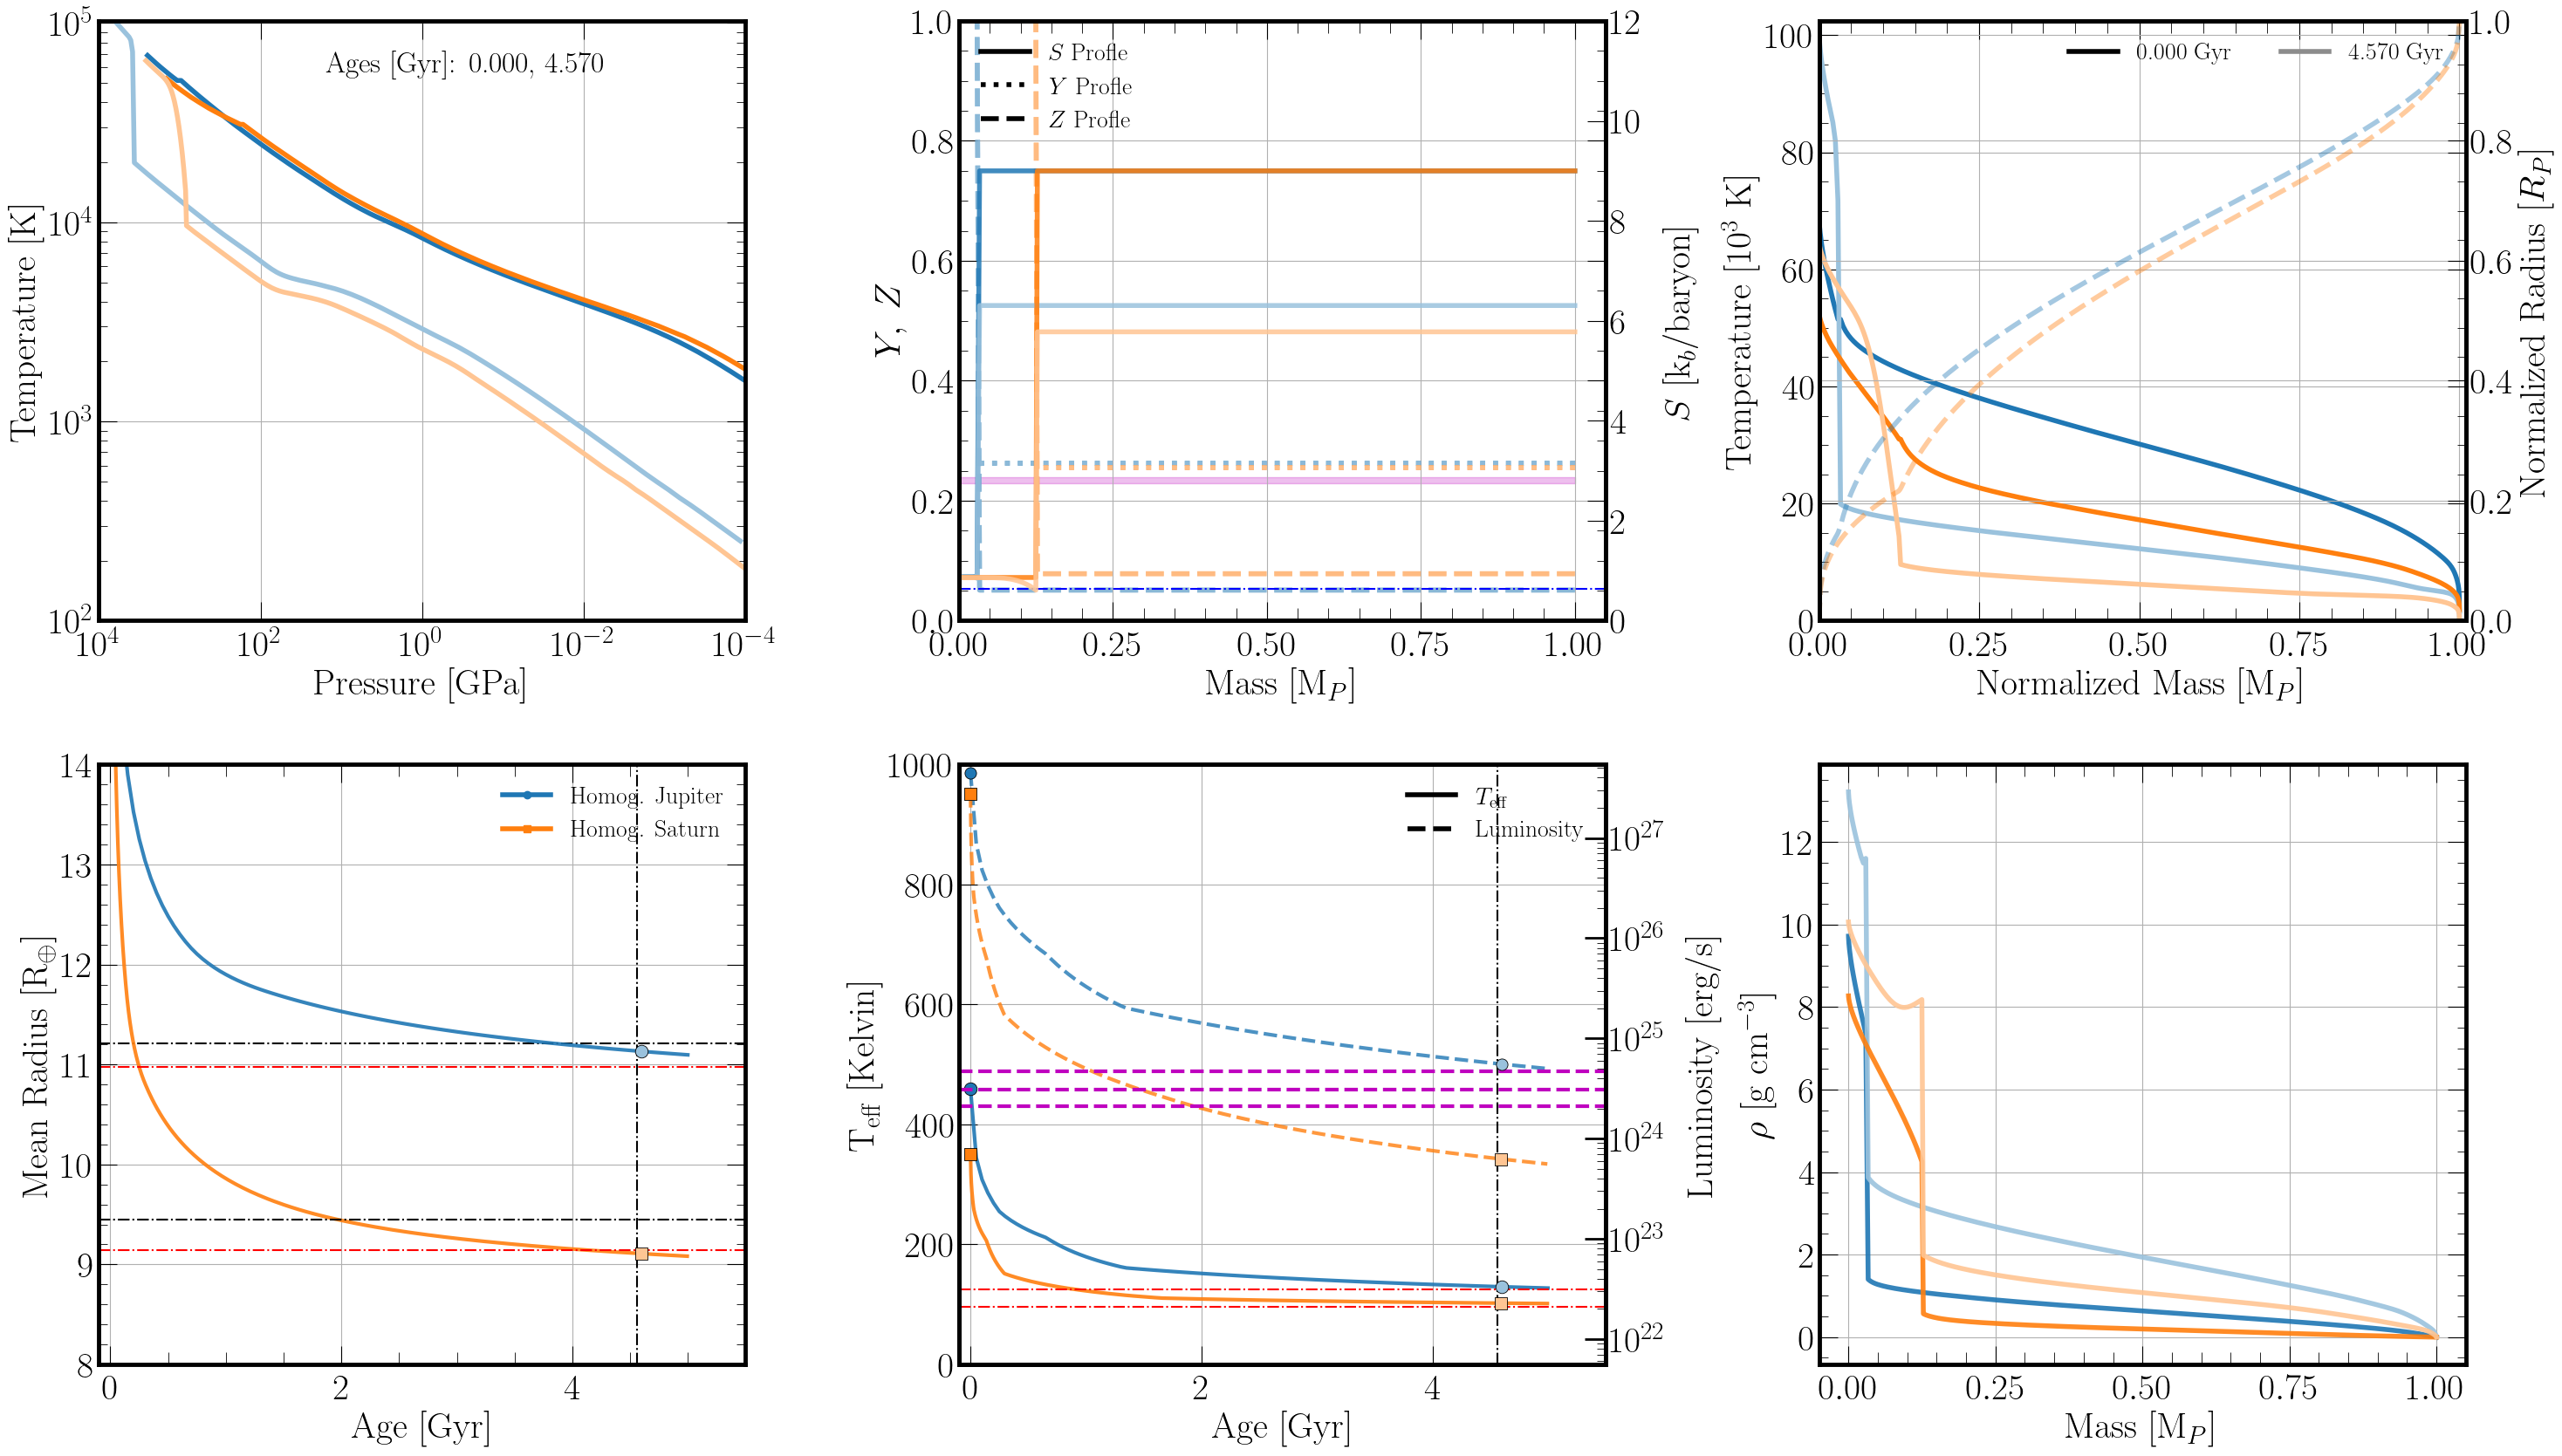

In [1]:
import plot_class

paths = [
    'parameter_examples/parameter_user_jup_noherain.ini',
    'parameter_examples/parameter_user_saturn_noherain_compactcore.ini',
]

init = plot_class.init_plot(paths = paths)

# specify legend labels for each model (in order of paths list)
labels = [
    r'Homog. Jupiter',
    r'Homog. Saturn',

]

init.age_plot(
    ages=[0, 4.57], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    panel_num = 6,
    rad_temp_plot=True,
)

**NOTE**: The logT vs. logP plot in the upper left hand corner shows that both planets start at a similar temperature, but the upper right does not. Looks can be deceiving: The upper-right plot is normalized mass vs. Temperature. The same normalized mass coordinate in Saturn corresponds to a significantly lower pressure to that of Jupiter. 

**PLOTTING NOTE**: When setting a planet name to a Solar System planet, `plot_class.py` will automatically detect it and provide reference values for that planet, such as the radii of Jupiter and Saturn (dash dotted lines in the lower left plot), the effective temperatures (bottom center, red dash-dot), luminosities (dashed purple), and atmospheric helium mass fractions for `Jupiter` and `Saturn` (upper center; faint purple region). 

## Uranus and Neptune (homogeneous)

Next, we will use two more config files: [`parameter_user_uranus.ini`](../parameter_examples/parameter_user_uranus.ini) and [`parameter_user_neptune.ini`](../parameter_examples/parameter_user_neptune.ini). In these, we set `planet = Uranus` and `planet = Neptune` respectively. We use the atmosphere boundary conditions of Graboske et al. (1975) by setting `bc_atm = g75`. Alternatively, you may use the more recent Ohno & Fortney (2023) BCs (descendants of Fortney et al. 2007) by setting `bc_atm = f07`, see `tutorial_subneptunes_superearths.ipynb`, whose sub-Neptune examples use `f07`-style boundary conditions.

Since Uranus and Neptune might be "ice giants," we use a high metal content. Uranus uses `Z_ini = 0.6` (~35× solar with $Z_\odot = 0.017$), and Neptune uses `Z_ini = 0.75` (~44× solar).

The metal EOS for these models is a 4:1:7 mixture of methane:ammonia:water number ratios. This is the default mixture available in precalculated tables. To use them, set `z_eos = ice_mixture` and ensure the following parameters:

```
water_eos = aqua
eos_tab = True
rock_mixtures = True
```

For Uranus, we lower the initial entropy to 4.5 k$_B$/baryon given the large interior metallicity, and insert a core mass of 4 earth masses (`mass_core = 4.0`).

For Neptune, we use 4 k$_B$/baryon since the higher `Z_ini = 0.75` produces a hotter envelope at the same entropy, and the same `mass_core = 4.0`.

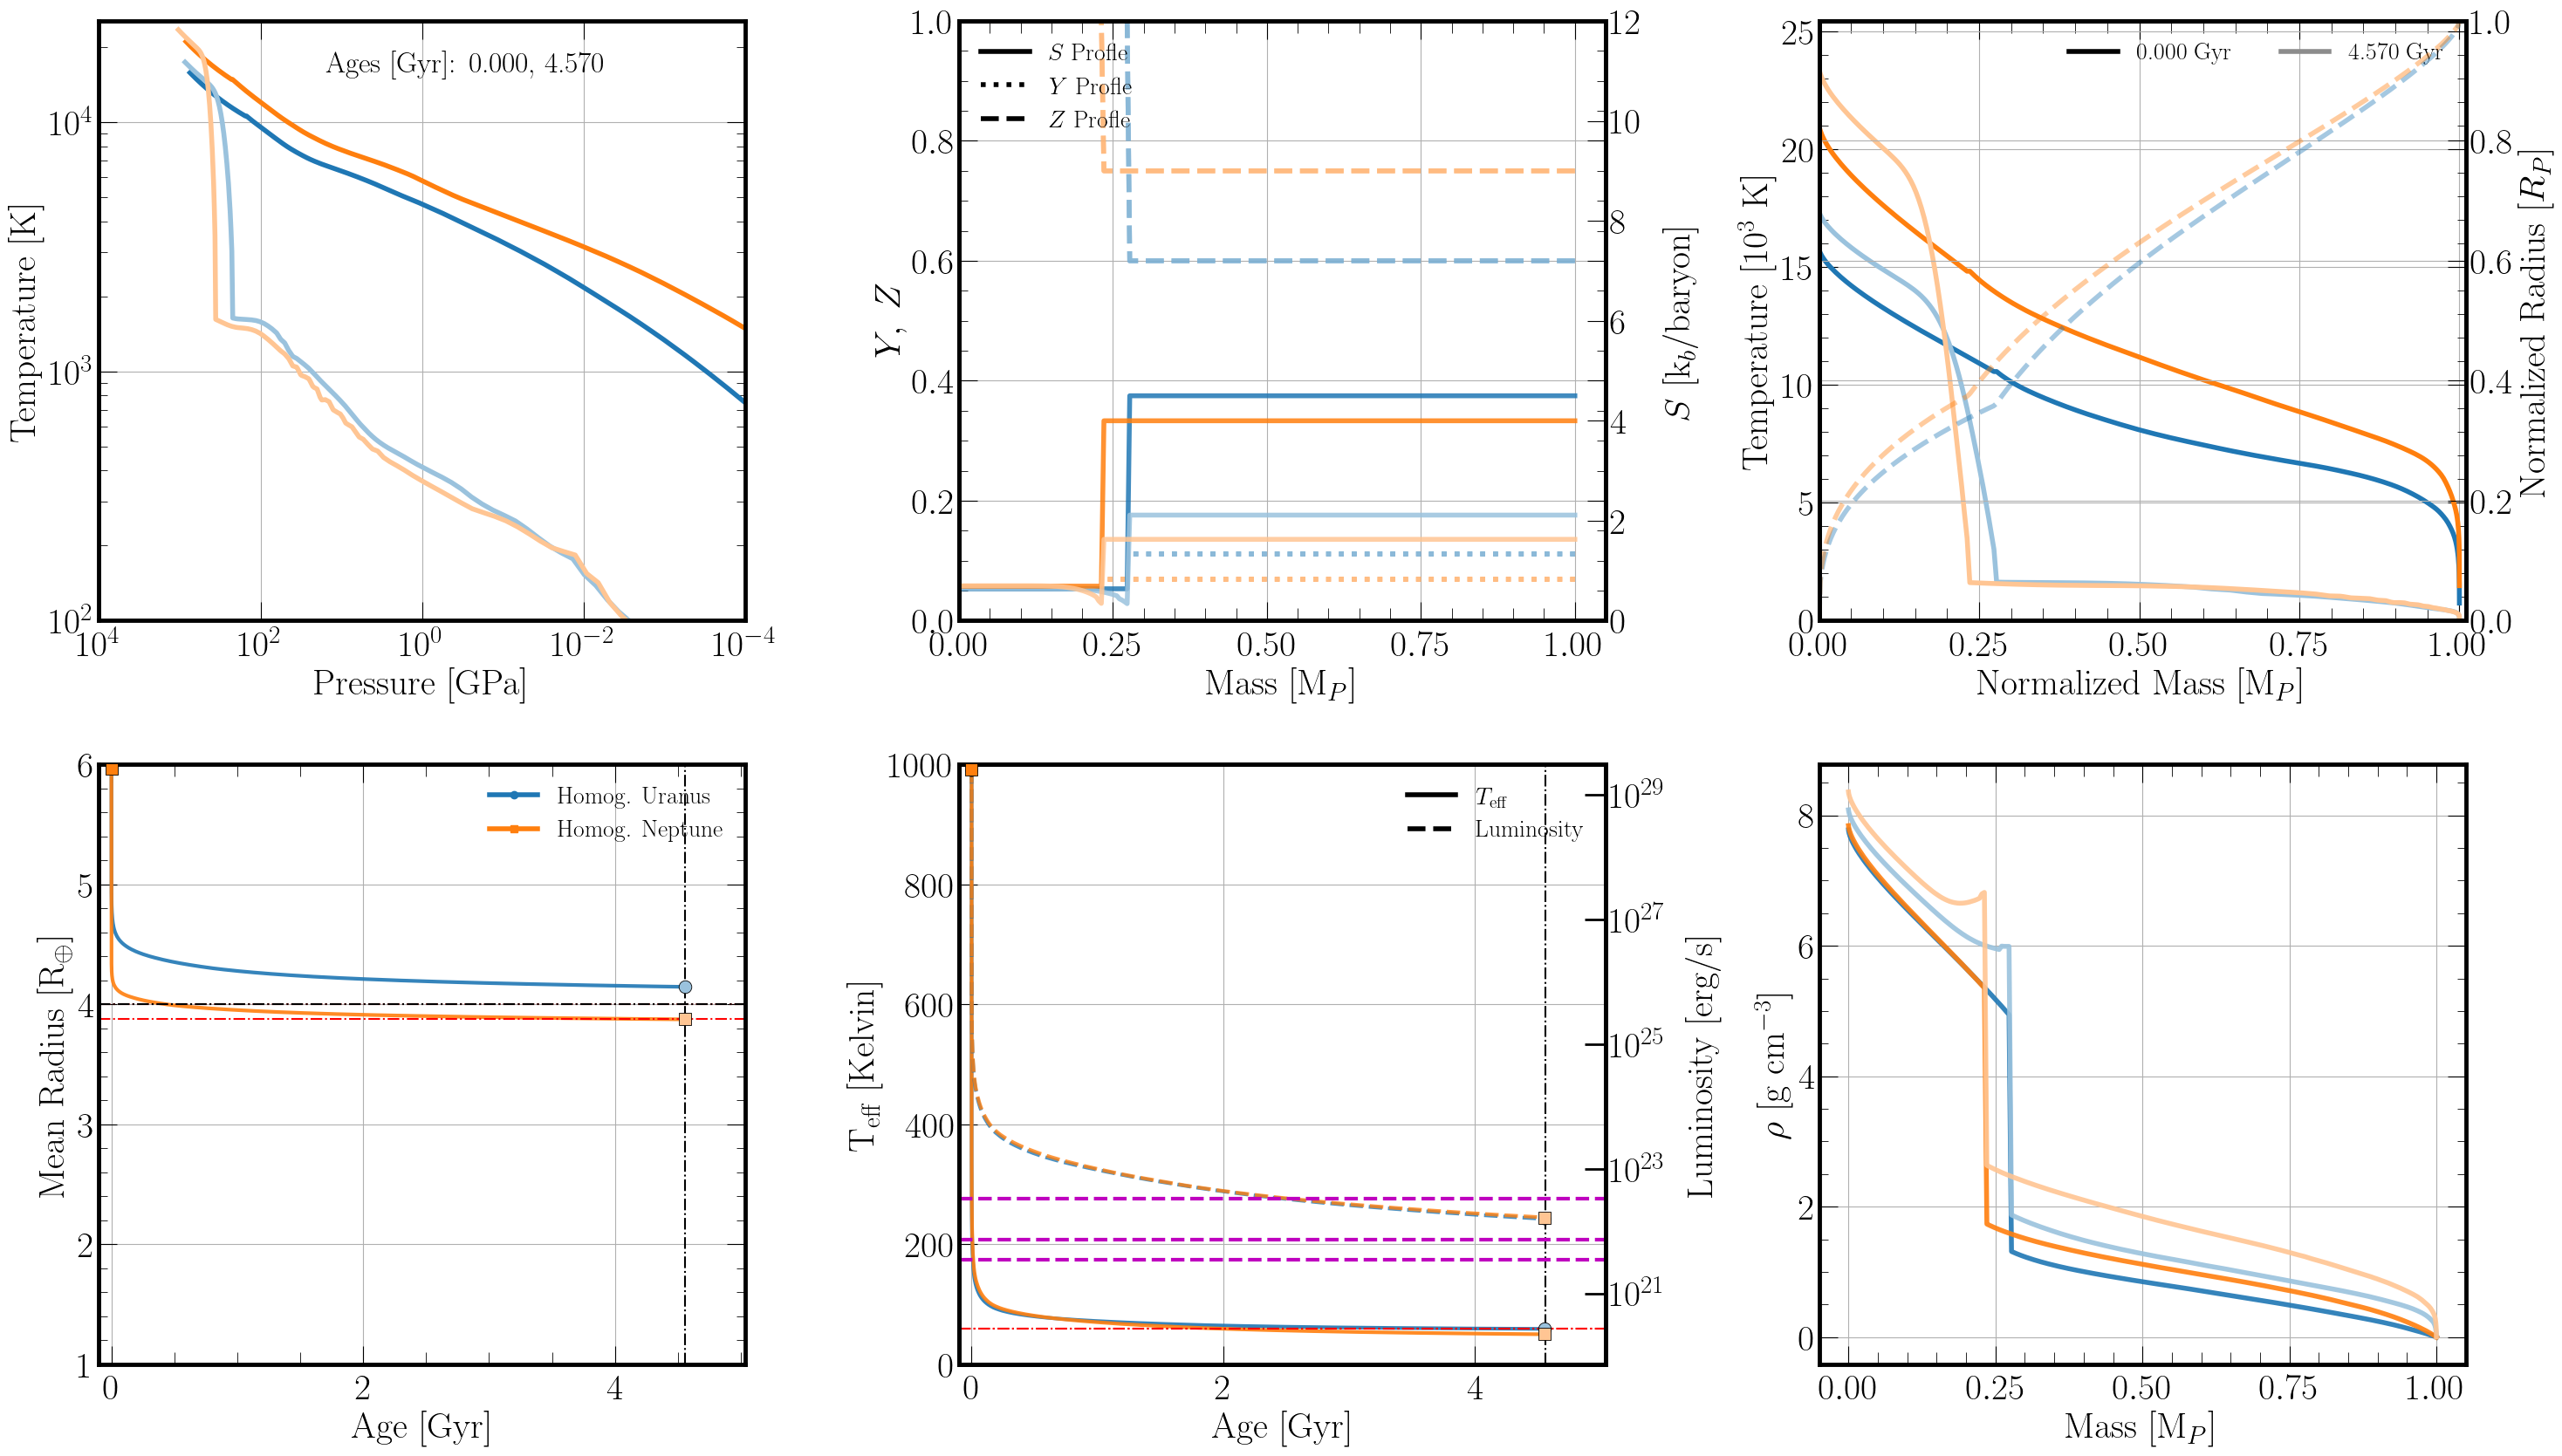

In [2]:
import plot_class

paths = [
    'parameter_examples/parameter_user_uranus.ini',
    'parameter_examples/parameter_user_neptune.ini',
]

init = plot_class.init_plot(paths = paths)

# specify legend labels for each model (in order of paths list)
labels = [
    r'Homog. Uranus',
    r'Homog. Neptune',

]

init.age_plot(
    ages=[0, 4.57], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    rad_temp_plot=True,
)

The purple lines in the luminosity and effective temperature plot (bottom center) show the intrinsic fluxes measured for Uranus (Irwin et al. 2025) and Neptune (Pearl \& Conrath 1991). This exercise, besides being a demonstration, also shows that simple adiabatic models are too luminous to explain the luminosities of both planets-- but of Uranus in particular. 

## Jupiter

Since Jupiter and Saturn are now expected to harbor large stable regions, or fuzzy cores (e.g., Wahl et al. 2017, Mankovich \& Fuller 2021), we need to construct inhomogeneous interiors for both planets. It is yet unclear whether these fuzzy cores are remnants from formation or whether they naturally arise through evolutionary processes (see Tejada Arevalo et al. 2025 for a discussion).

Here we will demonstrate inhomogeneous models of Jupiter and Saturn. To learn about how to set up the different inhomogeneous initial conditions, please see the `tutorial_inhomogeneous_evolution.ipynb` tutorial.

First, we will choose to construct the total $Z$ profile based on a total metal mass, and set `M_z = 42.5` in Earth masses. Then, we will set `mz_struct = True` to use the total Z mass instead of the `Z_ini` parameter. We then use a gaussian structure of $S$ and $Z$, and turn helium rain on (`helium_rain = True`) using a `misc_deltaT = 410`.

For demonstration purposes, we will keep `rotation=False`. However, if you'd like to experiment, set `rotation=True` and use the observed current rotation period of Jupiter in seconds, `period = 35730.42333333`, and an inferred moment of inertia value from the literature (Militzer \& Hubbard 2024): `C_MoI = 0.26393`. The angular frequency will be scaled according to the simulation present MoI and the present, real-world MoI, and keep the period constant. In all these rotation examples, `tof_calc = True`.

All of these parameters are shown in [`parameter_examples/parameter_user_jup_inhomog_gaussian_example2.ini`](../parameter_examples/parameter_user_jup_inhomog_gaussian_example2.ini).

The following are versions of the models published in Tejada Arevalo et al. (2025) and Sur et al. (2025).

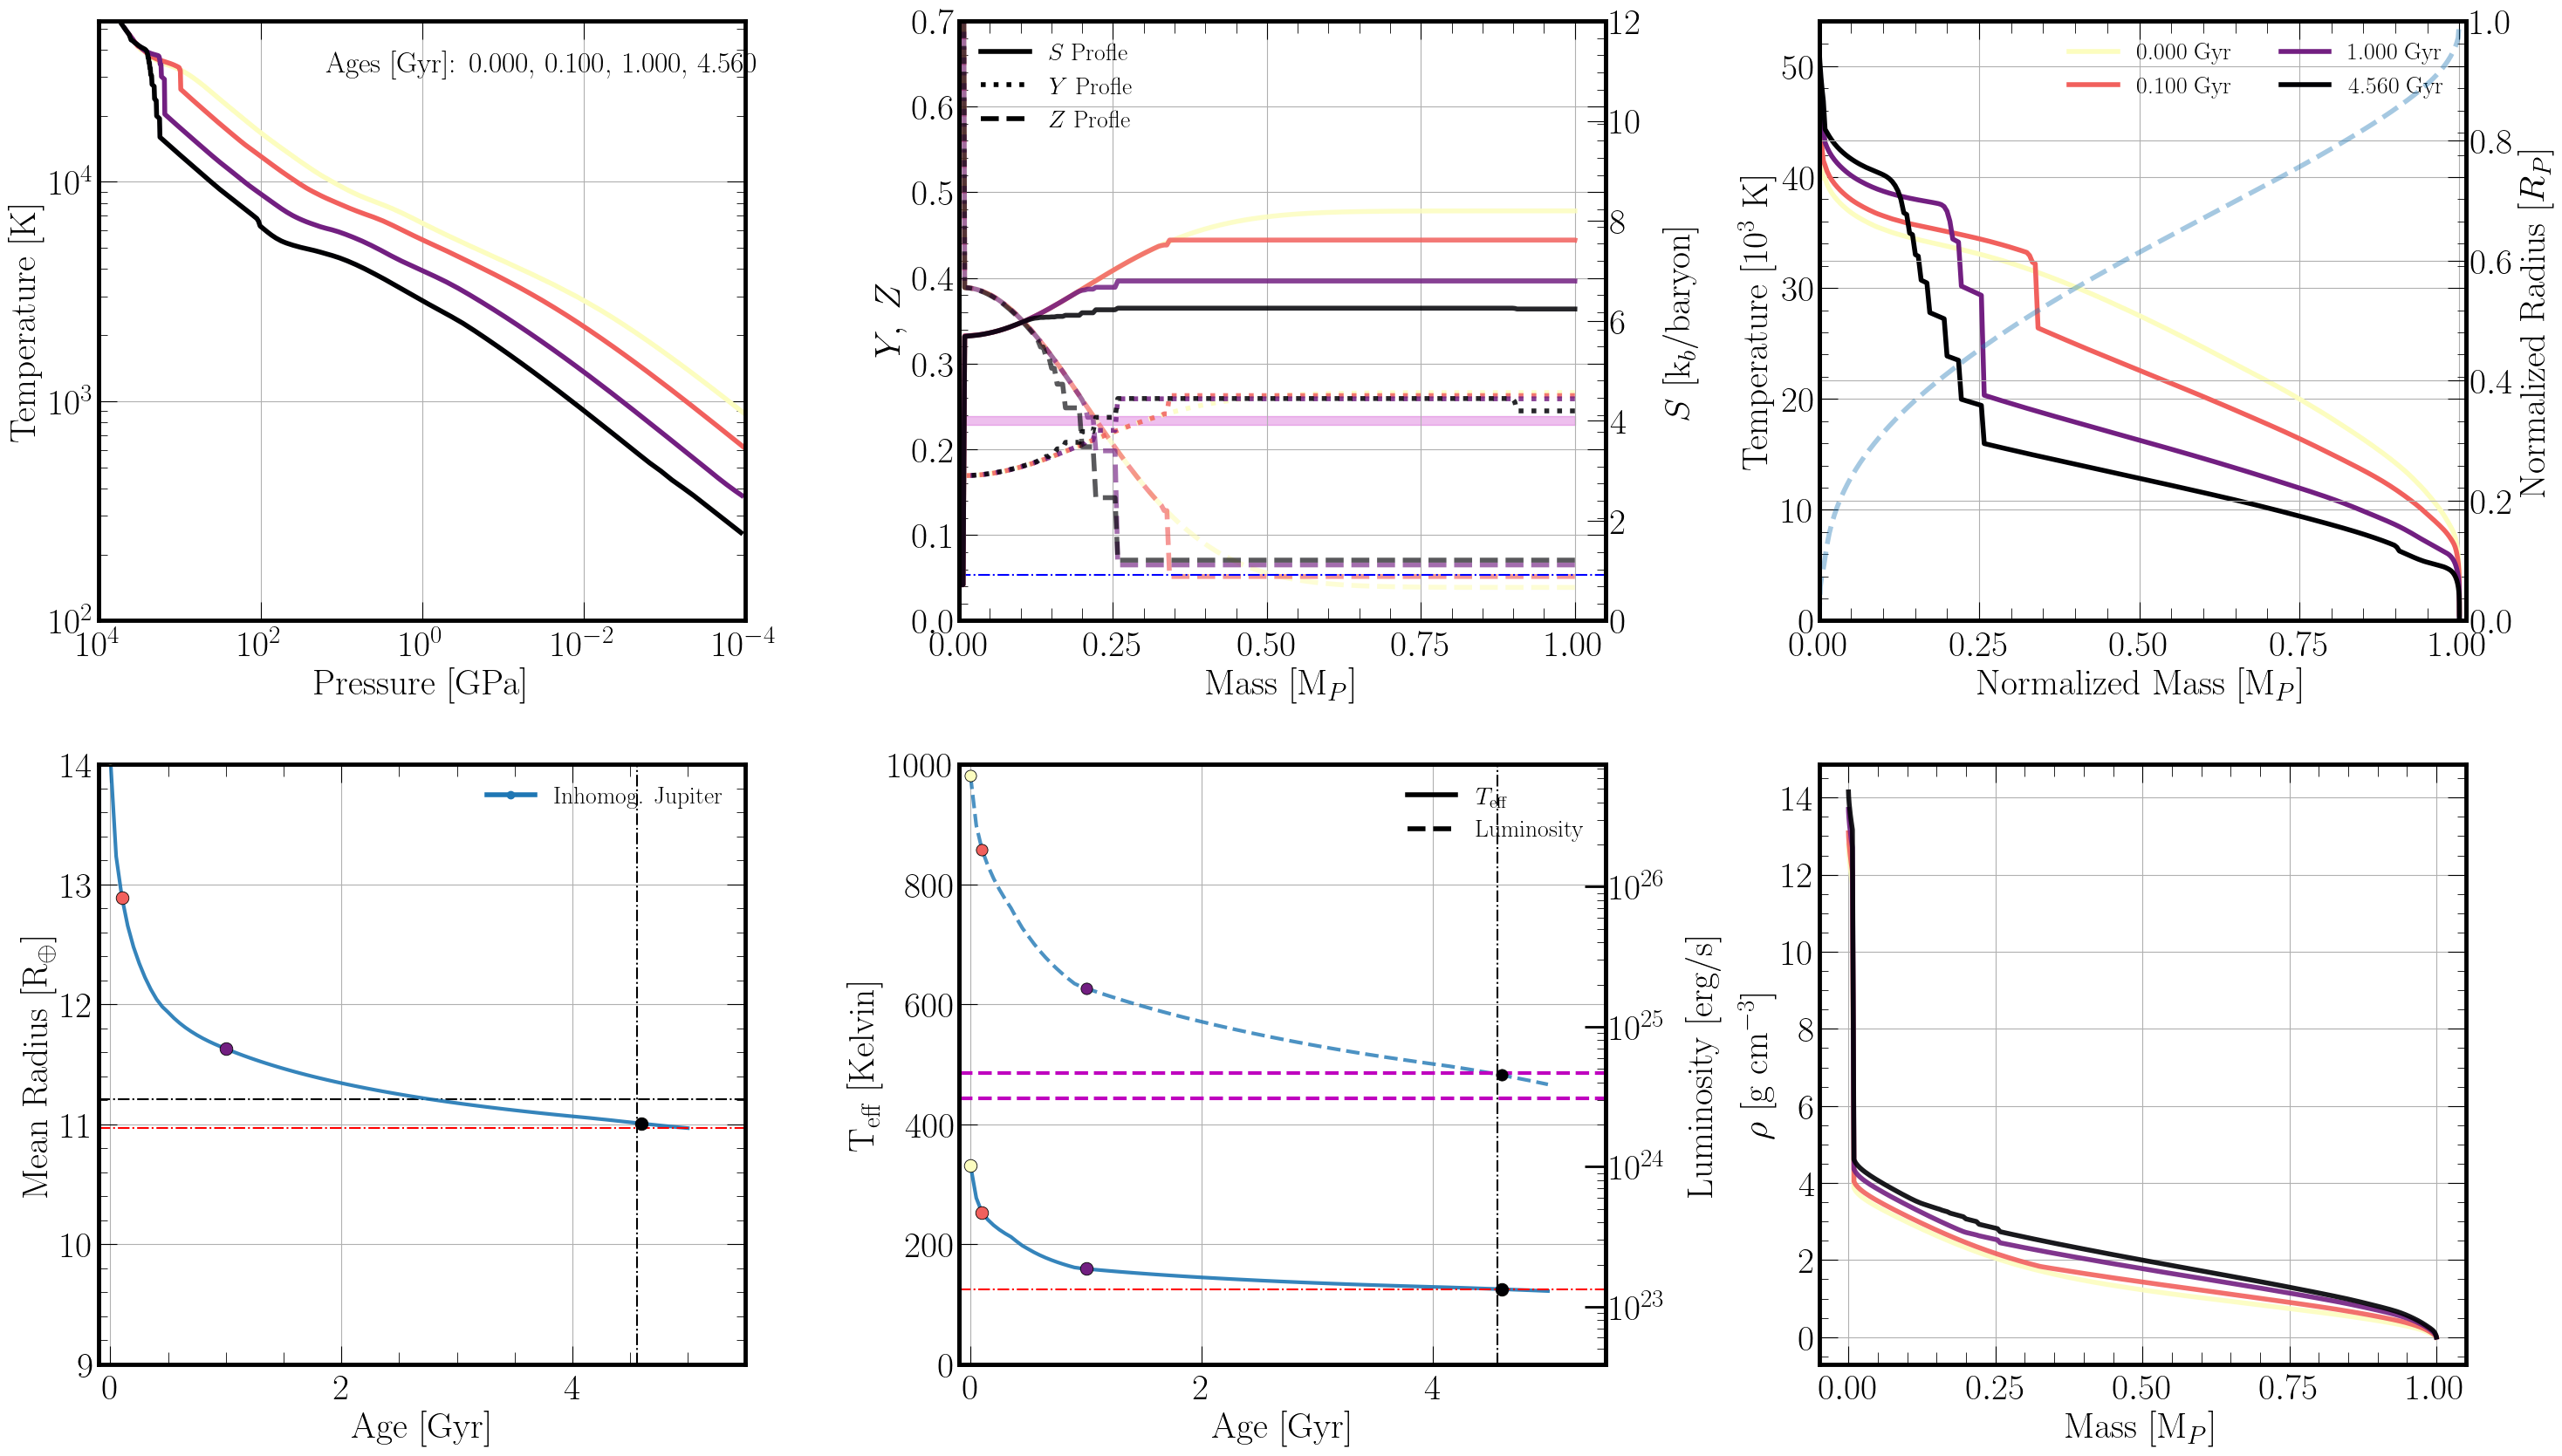

In [3]:
import plot_class

paths = [
    'parameter_examples/parameter_user_jup_inhomog_gaussian_example2.ini',
]

init = plot_class.init_plot(paths = paths,
                            plot_Js=False) # set this to True if rotation=True to see J2 and J4 evolution in the age plot

# specify legend labels for each model (in order of paths list)
labels = [
    r'Inhomog. Jupiter',
]

init.age_plot(

    ages=[0, 0.1, 1.0, 4.56], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    panel_num = 6,
    rad_temp_plot=True,

)

Since the inner regions heat up, as can be compared in the upper right hand plot, the inner iron core receives inward luminosity/flux. Feel free to adjust the conductivity parameters to adjust its behavior at Gyr ages.

## Saturn

Saturn likely has a large stable region, extending out to 60% of its current radius, according to kronoseismology analysis by Mankovich and Fuller (2021). Since convective mixing erodes initially stable regions, we will set up an initial Saturn model that is mostly stable, and have it experience helium rain to create a stable outer region in its helium rain region. Together, the fuzzy core and helium rain regions could reproduce the observed gravity modes (Su et al. 2026).

The metal mass fraction profile of Saturn is better constrained than that of Jupiter, and its initial structure could be better constructed using `struct` profiles. We will use the following struct coordinates and deltas:

```
initial_profiles_S = struct
initial_profiles_Y = struct
initial_profiles_Z = struct
initial_profile_name = None
z_init_coords = [0,0.2,0.4,0.6,0.8,1.0]
y_init_coords = []
s_init_coords = [0,0.2,0.4,0.6,0.8,1.0]
z_init_deltas = [-0.35, -0.32, -0.1, -0.05, 0]
y_init_deltas = []
s_init_deltas = [1.86,1.78,0.58,0.5,0.5]
```

and set a total heavy element mass of 20 earth masses (`M_z = 20.0`). Given its greater outer metallicity, we will start this Saturn model outer region at 7.9 k$_B$/baryon (`S_ini = 7.9`).

Again, we do not use rotation here because models with rotation take much longer to run. However, feel free to use `rotation=True`. We used a period of `380305.26315789474` and a `C_MoI = 0.21289473684210525`.

We will also use `planet = Saturn`, set the boundary condition `bc_atm = c23`, and turn on clouds and irradiation (`irradiation = True`, `cloud = True`). The example .ini ships with a small stub core (`mass_core = 0.5`, `mass_core_fe = 0`) since this Saturn model derives most of its high-Z budget from the inhomogeneous envelope rather than from a compact core. To follow the published Sur et al. (2025a) Saturn setup more closely, you can edit the .ini to use a larger compact core (e.g., `mass_core = 4`, `mass_core_fe = 1.32`).

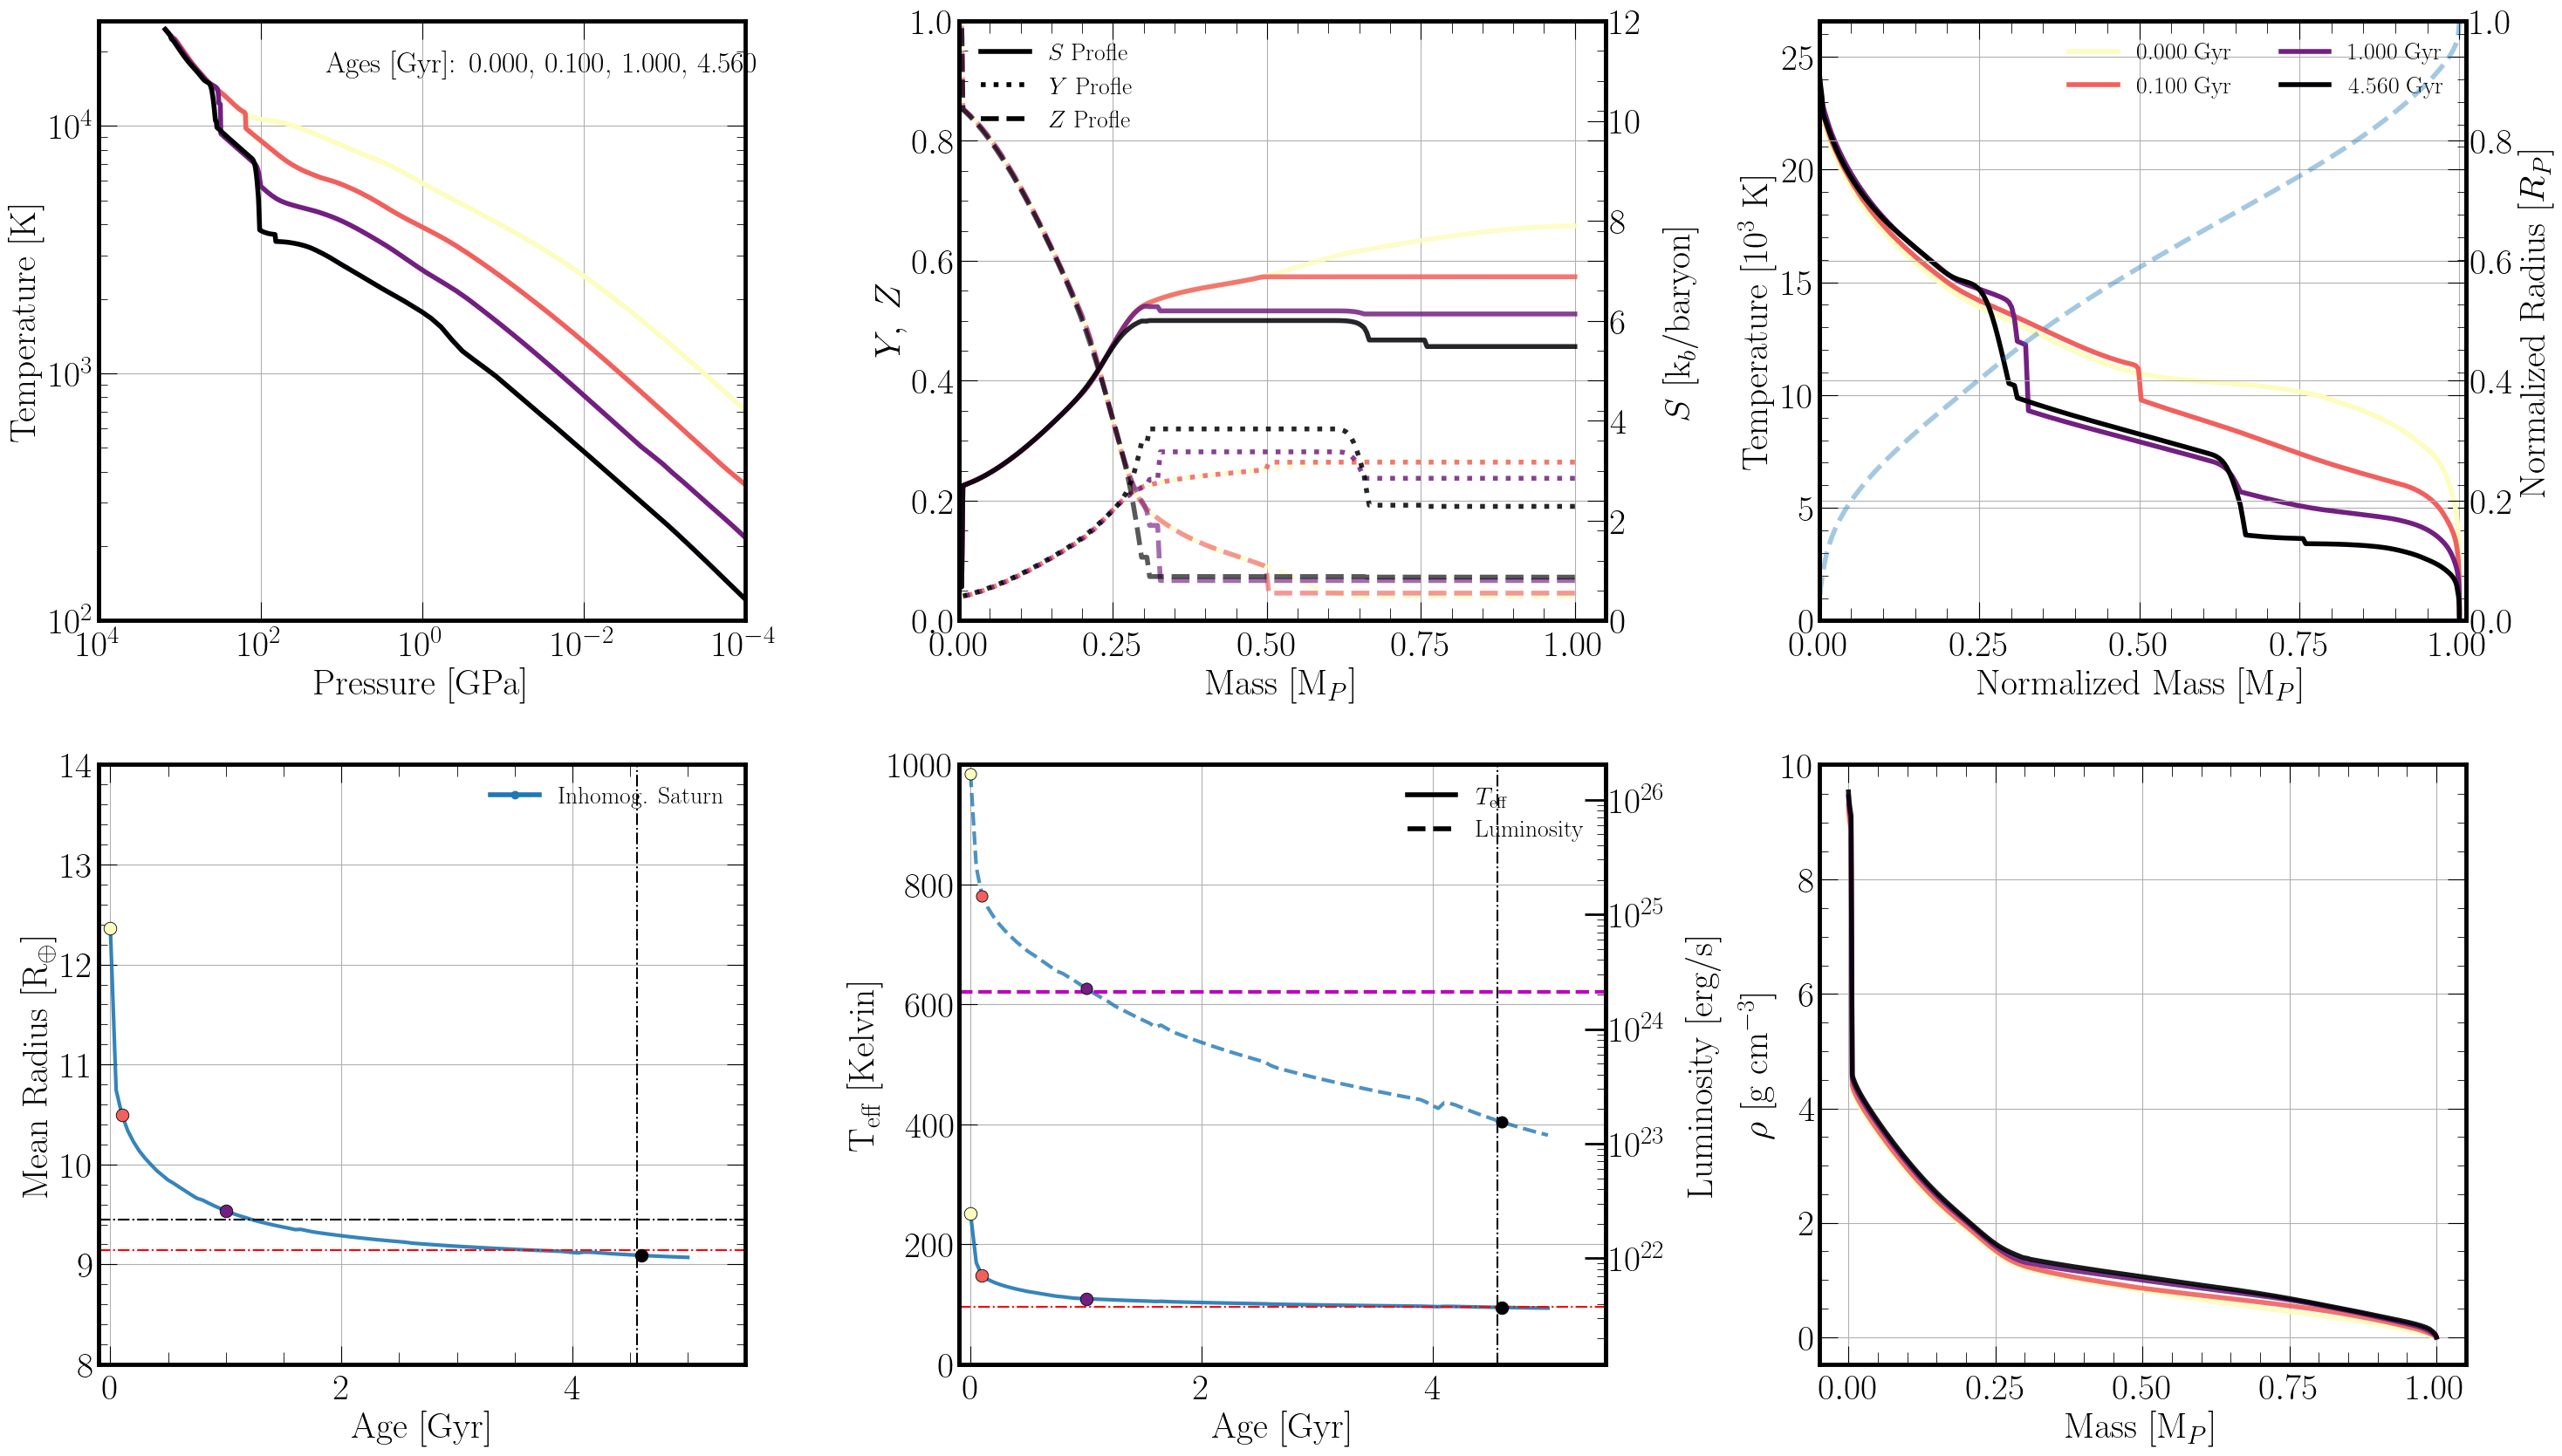

In [4]:
import plot_class

paths = [
    'parameter_examples/parameter_user_saturn_inhomog_struct_example1.ini',
]

init = plot_class.init_plot(paths = paths,
                            plot_Js = False, # set this to True if rotation=True to see J2 and J4 evolution in the age plot
                            )

# specify legend labels for each model (in order of paths list)
labels = [
    r'Inhomog. Saturn',
]

init.age_plot(
    ages=[0, 0.1, 1.0, 4.56], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    panel_num = 6,
    rad_temp_plot=True,

)

This particular inhomogeneous model of saturn undergoes more helium rain than those published by Sur et al. (2025), primarily because I've chosen a smaller helium rain scale height at 50 km (`Hr_y = 5e6`). Saturn is famously oblate, caused by its fast rotation. A better radius agreement can be obtained with this model by simply taking out its compact core, reducing its total overall heavy element mass with `M_z`, and setting `rotation=True` and compare its equatorial radius evolution `Req_TOF`. 

## Uranus

The following Uranus model is a variation, lower resolution, and without rotation, example of the model presented in Tejada Arevalo (2025).

Here we will once again set the `struct` profiles. Just like in our homogeneous examples above, we will set `z_eos = ice_mixtures`. Recall that this ice mixture table only provides a 4:1:7 methane:ammonia:water mixture ratio. You're free to follow the `tutorial_eos.ipynb` for instructions how to use the `ice_eos.py` module independently, and create your own mixtures. I did this in Appendix A, Figure A2, of Tejada Arevalo (2025) to check the dependencies on C:N:O ratios. There is, indeed, a large dependence, so proceed with caution when using ice mixtures.  

These inhomogeneous models will be variations of the ones published in Tejada Arevalo (2025):
```
z_init_coords = [0, 0.3, 0.4, 0.42, 0.6, 0.62, 0.88, 0.92, 0.94, 1.0]
y_init_coords = []
s_init_coords = [0, 0.3, 0.4, 0.42, 0.6, 0.62, 0.88, 0.92, 0.94, 1.0]
f_rock_init_coords = [0, 0.3, 0.4, 0.42, 0.6, 0.62, 0.88, 0.92, 0.94, 1.0]
z_init_deltas = [0, 0, -0.1, 0, -0.05, 0, -0.05, -0.43, 0]
y_init_deltas = []
f_rock_init_deltas = [0, 0, 0, 0, 0, 0, 0, -0.4, 0]
s_init_deltas = [0, 0, 0.55, 0, 0.25, 0, 0.1, 2.22, 0]
```

Make sure to set `mz_struct = False`, since we're not going to use the total `M_z` here. This is because the interior $Z$ profiles are even more of a mystery for these planets, so the degrees of freedom due to the inhomogeneous profiles is much larger. Instead, the code will tell you at the beginning how many earth masses of heavy elements your profile gives. 

Next we will set `bc_atm = g75` to use the old Graboske fits. While you can also use `bc_atm = f07`, this may require some parameter nudging to make work with these profiles. For now, we will use the `g75` BCs for demonstration purposes only. 

Since there are many line segments here, we'll benefit from some gaussian smoothing. Set `struct_smooth=True` and use a `struct_sigma = 2.0`. Higher sigma values will produce more smoothed profiles. Next we will set the equilibrium temperature to `t_eq = 55`, start the outer envelope at `S_ini = 5.0` k$_B$/baryon with an outer metallicity of `Z_ini = 0.35`, and insert a small compact core (`mass_core = 0.5`) with an even smaller iron sub-core (`mass_core_fe = 0.1`). All of these choices are collected in [`parameter_examples/parameter_user_uranus_inhomog_struct_example1.ini`](../parameter_examples/parameter_user_uranus_inhomog_struct_example1.ini). Feel free to open it and experiment.

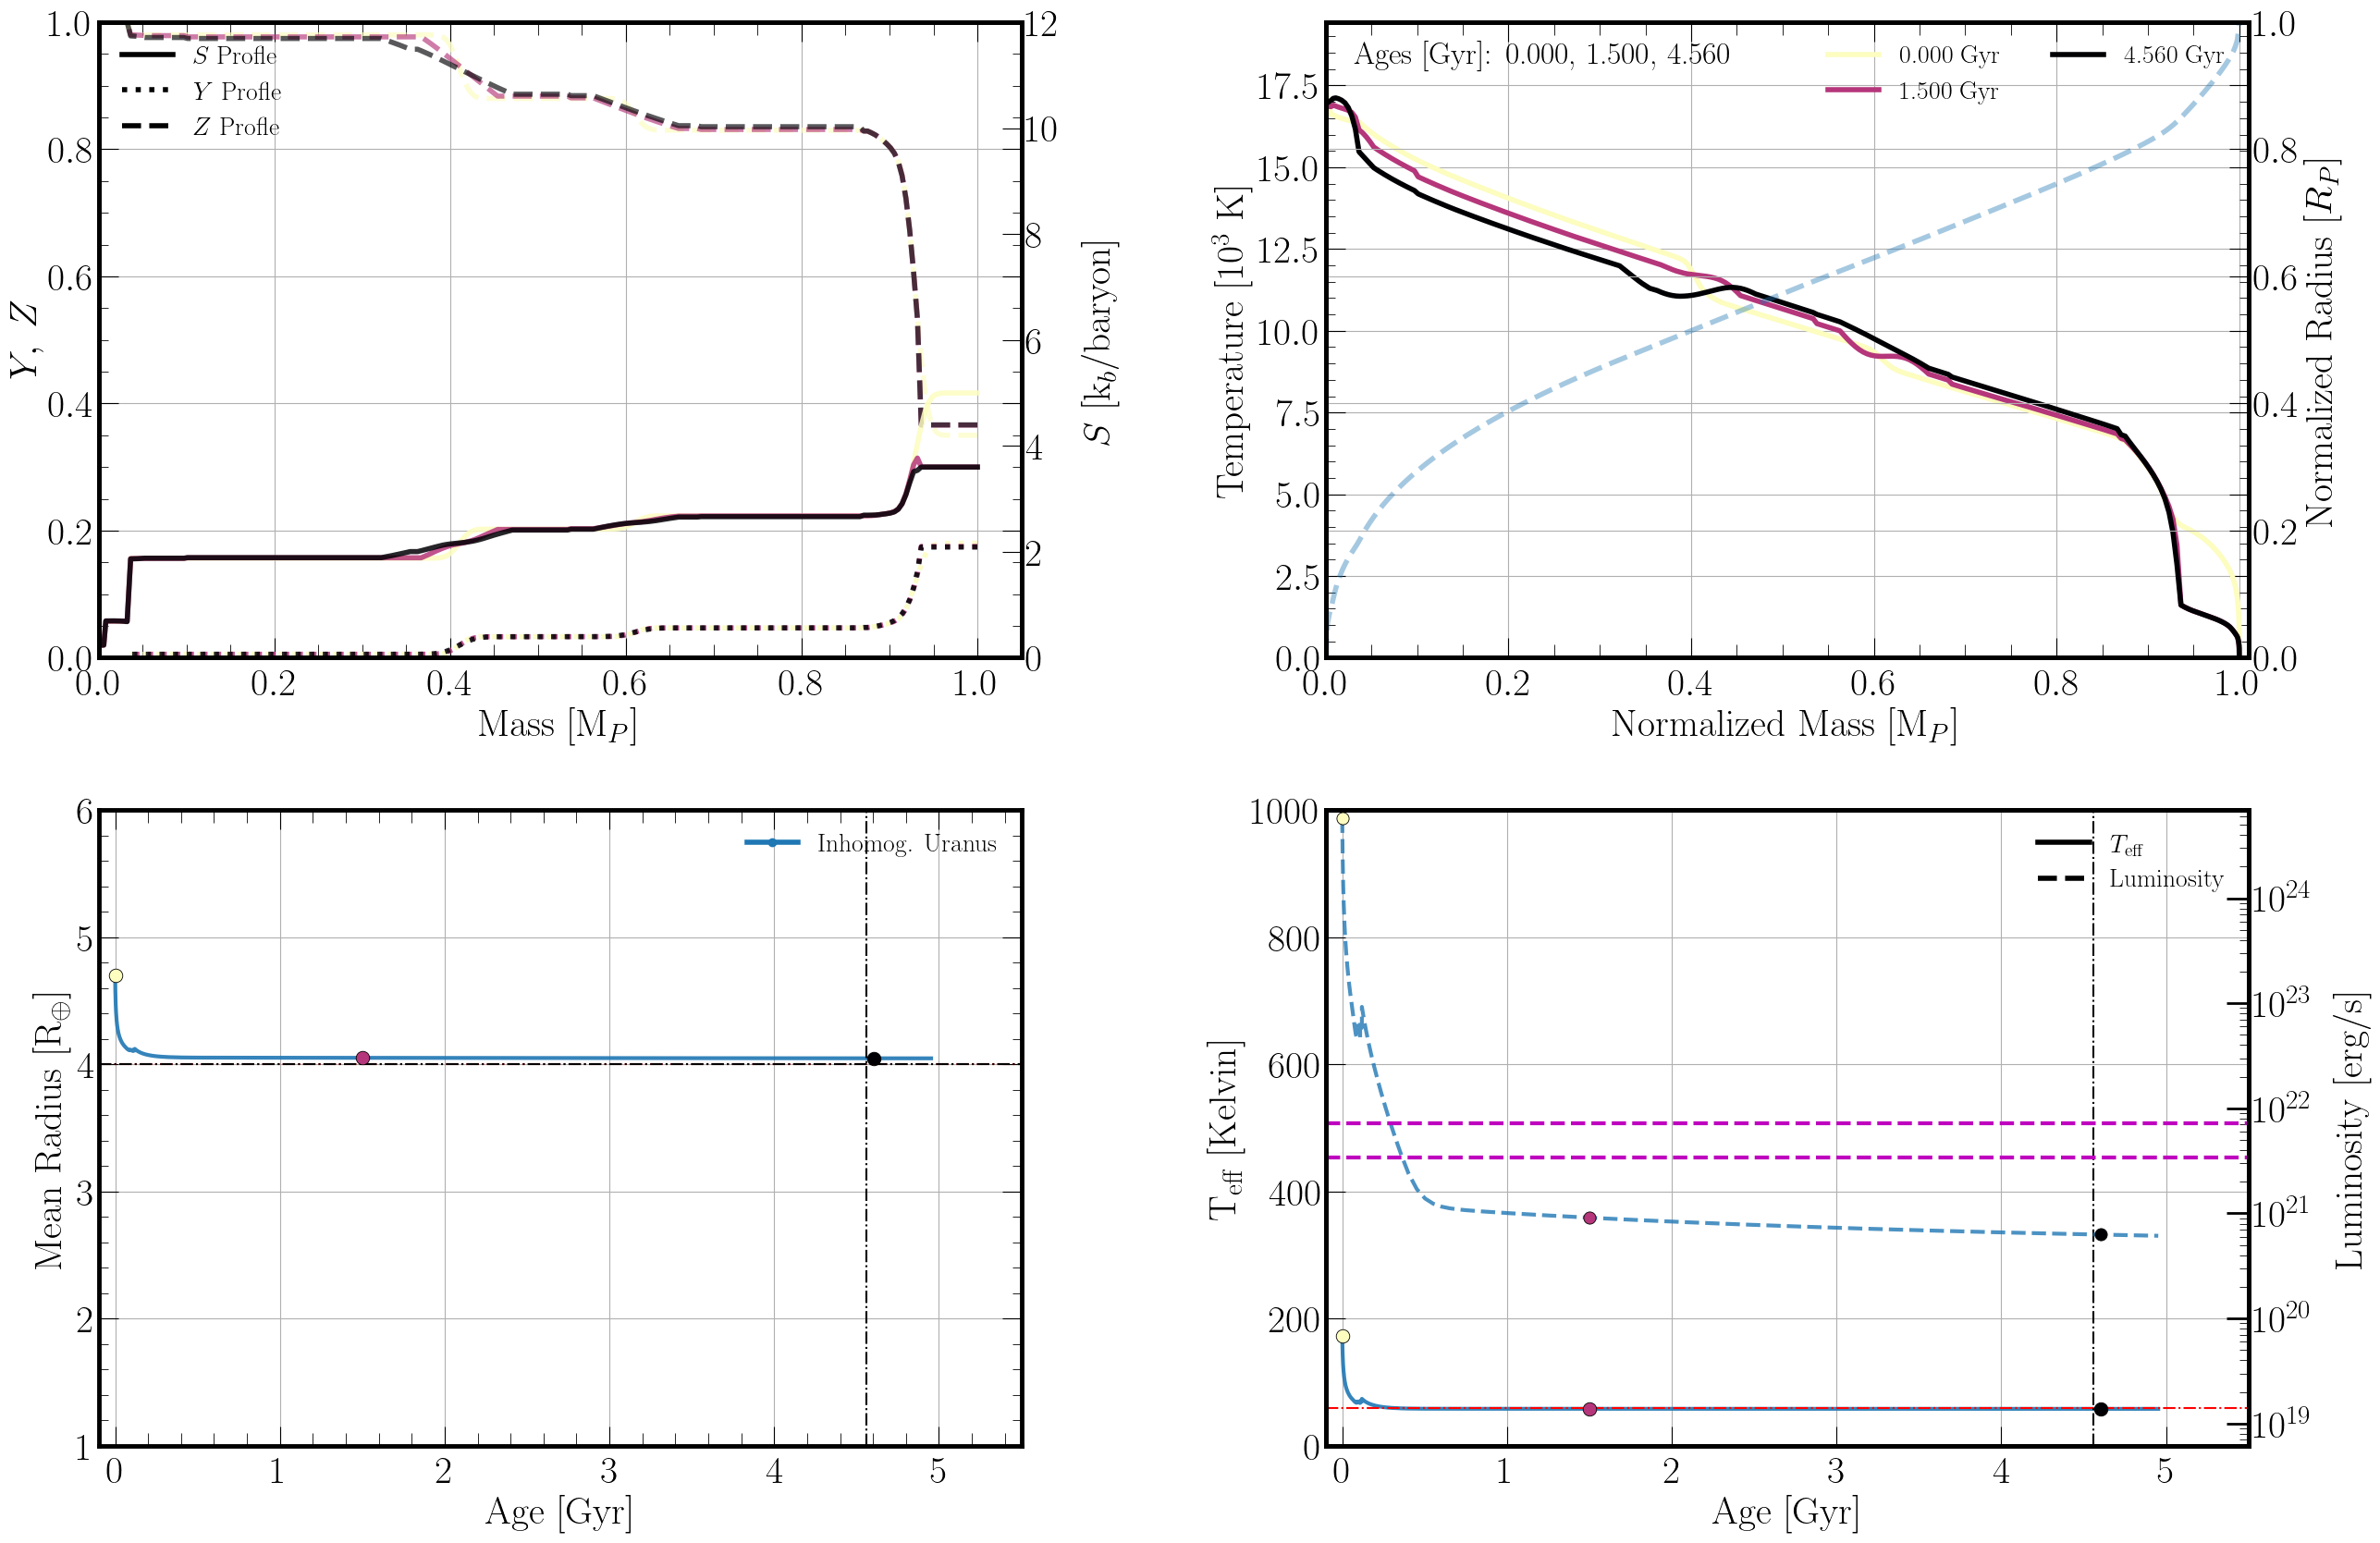

In [8]:
import plot_class

paths = [
    'parameter_examples/parameter_user_uranus_inhomog_struct_example1.ini',
]

init = plot_class.init_plot(paths = paths,
                            plot_Js = False, # set this to True if rotation=True to see J2 and J4 evolution in the age plot
                            )

# specify legend labels for each model (in order of paths list)
labels = [
    r'Inhomog. Uranus',
]

init.age_plot(
    ages=[0, 1.5, 4.56], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    panel_num = 4,
    rad_temp_plot=True,

)

IMPORTANT NOTE: This Uranus model does not match the observables outlined in Tejada Arevalo (2025) since it is not rotating and is lower resolution. This is needed for demonstration purposes, since the full models take ~hrs to run.